In [1]:
import importlib
import peak_gene_utils
importlib.reload(peak_gene_utils)
from peak_gene_utils import *

from utils import *
import squidpy as sq
import os

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

## Load data

### Annotate cCRE df with three nearest genes

In [2]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [3]:
niche_pca_anno = sc.read_h5ad("../../h5ad_files/niche_pca_annotated_sp.h5ad")

In [4]:
expr.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()
atac.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()

In [5]:
# get nichePCA pca matrix
X_npca = np.load("../X_npca.npy")
expr.obsm["X_npca"] = X_npca

## Run Descart

In [8]:
import time

In [69]:
import joblib

In [75]:
num_select_peak = 10000
seed_base = 1
tf = 'tfidf2'
pc = 10
k = 20
similarity = 'cosine'
iter_time = 4
spmethod = 'threshold'
neighbor = 5
sp_dist = 'recip'
pre_select = 'highest'
peaks_num = 50000
distance = 'euclidean'
r = 0.5

'''
start_time = time.time()

#adata = sc.AnnData(adata_raw.X,dtype = 'float32')
idx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

end_time = time.time()

elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")

descart_output = {
    'idx': idx,
    'sorted_index': sorted_index,
    'simi_matrix': simi_matrix,
    'idx_all': idx_all,
    'scores': scores,
    'selected_peaks_data': selected_peaks_data,
    'similarity_matrix_acb': similarity_matrix_acb,
    'similarity_matrix_spatial': similarity_matrix_spatial
}

joblib.dump(descart_output, 'module_cache/descart_output_r0.5.pkl')  # You can customize the filename based on parameters
print("Saved run_descart output.")
'''

'\nstart_time = time.time()\n\n#adata = sc.AnnData(adata_raw.X,dtype = \'float32\')\nidx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)\n\nend_time = time.time()\n\nelapsed_time = end_time - start_time\nprint(f"Running time: {elapsed_time:.6f} seconds")\n\ndescart_output = {\n    \'idx\': idx,\n    \'sorted_index\': sorted_index,\n    \'simi_matrix\': simi_matrix,\n    \'idx_all\': idx_all,\n    \'scores\': scores,\n    \'selected_peaks_data\': selected_peaks_data,\n    \'similarity_matrix_acb\': similarity_matrix_acb,\n    \'similarity_matrix_spatial\': similarity_matrix_spatial\n}\n\njoblib.dump(descart_output, \'module_cache/descart_output_r0.5.pkl\')  # You can customi

In [78]:
descart_output = joblib.load('module_cache/descart_output_r0.5.pkl')

# Unpack the variables
idx = descart_output['idx']
sorted_index = descart_output['sorted_index']
simi_matrix = descart_output['simi_matrix']
idx_all = descart_output['idx_all']
scores = descart_output['scores']
selected_peaks_data = descart_output['selected_peaks_data']
similarity_matrix_acb = descart_output['similarity_matrix_acb']
similarity_matrix_spatial = descart_output['similarity_matrix_spatial']

print("Loaded cached output.")

Loaded cached output.


In [79]:
start_time = time.time()
pdist_ = peak_modules_(selected_peaks_data=selected_peaks_data, similarity_matrix=simi_matrix, method='complete')
pdist_ = (pdist_+pdist_.T)/2
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")
print("Peak modules calculation has been done.")

pdist_.shape

Running time: 4.450225 seconds
Peak modules calculation has been done.


(10000, 10000)

In [11]:
non_diagonal_values = pdist_[np.triu_indices(pdist_.shape[0], k=1)]
peak_similarity = np.copy(pdist_)
thd = np.percentile(non_diagonal_values, 99.5)
peak_similarity[peak_similarity > thd] = thd
peak_distance = thd - peak_similarity
np.fill_diagonal(peak_distance, 0)

## Get peak modules

/nfs/home/students/l.reich/tangram/src/Descart/utils.py:1081: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = sch.linkage(peak_distance, method=method)


Cluster labels: [2 3 5 ... 5 5 5]


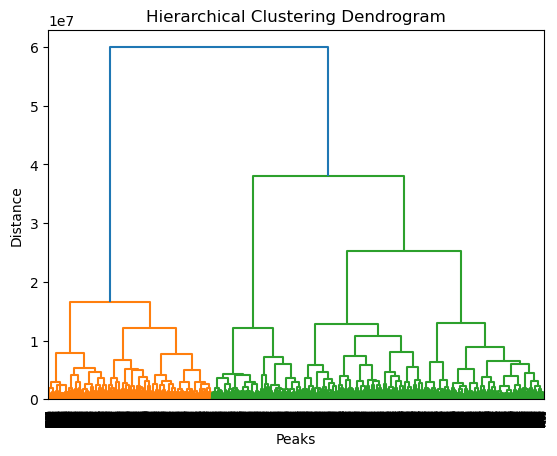

Number 1: Count = 1193, Proportion = 11.93%
Number 2: Count = 2113, Proportion = 21.13%
Number 3: Count = 1829, Proportion = 18.29%
Number 4: Count = 2439, Proportion = 24.39%
Number 5: Count = 2426, Proportion = 24.26%


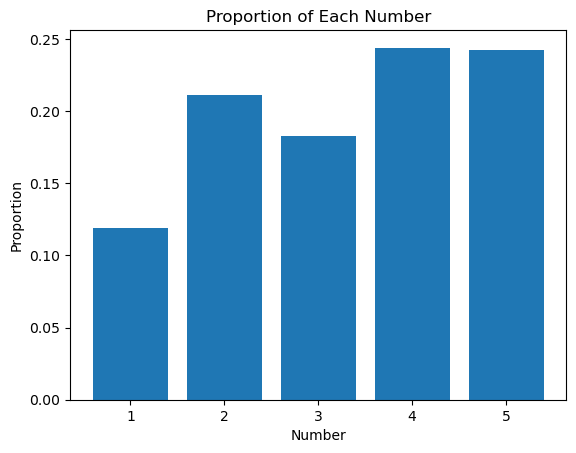

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


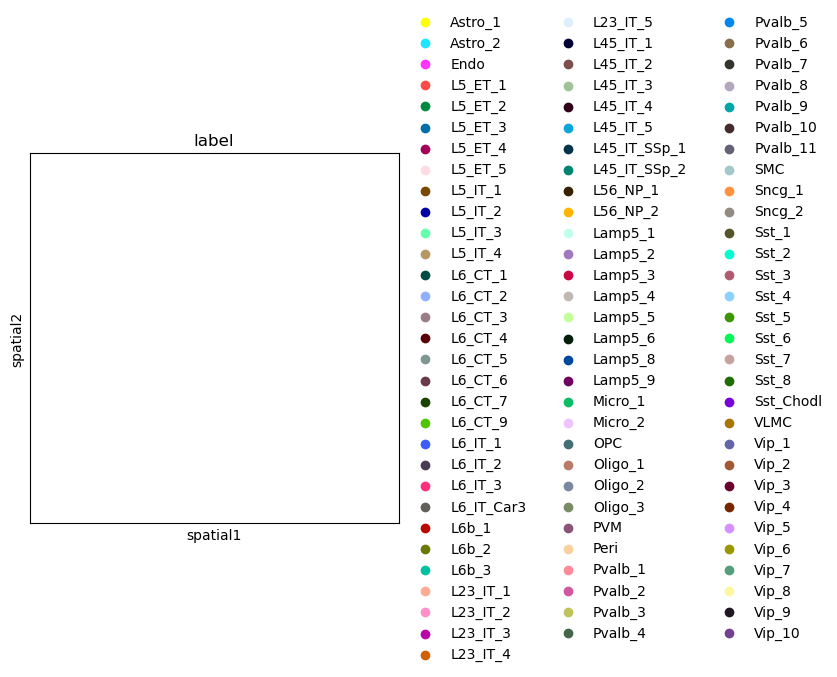

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


Number of peaks in module 1: 1193
Visualize peak module of label 1:
9999


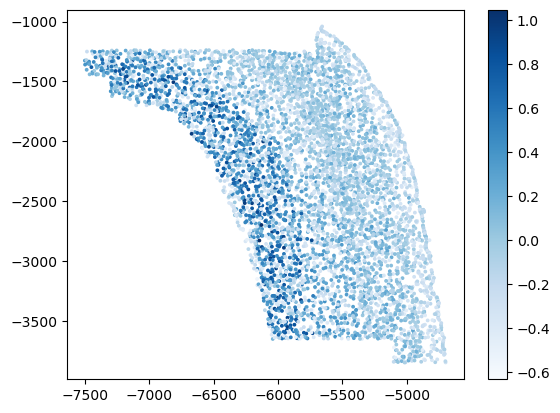

Number of peaks in module 2: 2113
Visualize peak module of label 2:
9999


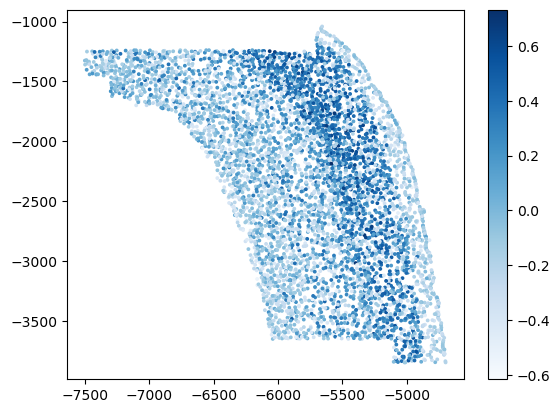

Number of peaks in module 3: 1829
Visualize peak module of label 3:
9999


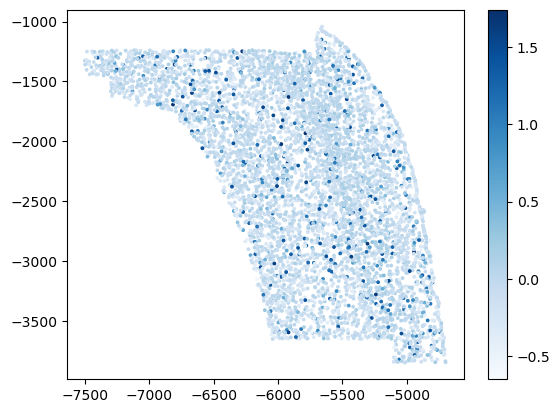

Number of peaks in module 4: 2439
Visualize peak module of label 4:
9999


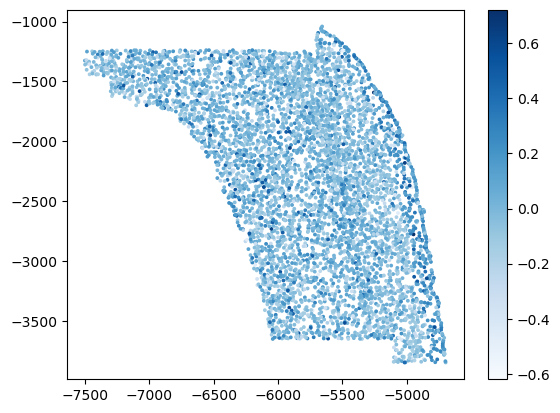

Number of peaks in module 5: 2426
Visualize peak module of label 5:
9999


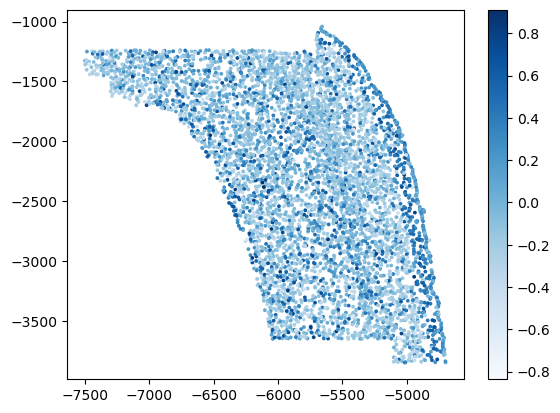

In [12]:
Z,labels = peak_module_cluster(atac,idx,peak_distance,"ward",num_clusters = 5)

In [84]:
cluster_output = {
    'Z': Z,
    'labels': labels
}

joblib.dump(cluster_output, 'module_cache/peak_modules_r0.5_k5.pkl')
print("Saved peak module clustering output.")

Saved peak module clustering output.


In [85]:
cluster_output = joblib.load('module_cache/peak_modules_r0.5_k5.pkl')

Z = cluster_output['Z']
labels = cluster_output['labels']

print("Loaded peak module clustering from cache.")

Loaded peak module clustering from cache.


In [13]:
def compute_linkage(peak_distance, method='ward'):
    return sch.linkage(peak_distance, method=method)

def get_cluster_labels(Z, num_clusters):
    return sch.fcluster(Z, t=num_clusters, criterion='maxclust')

In [14]:
# Use the existing AnnData with spatially variable peaks
# Ensure the accessibility matrix is log-transformed (if not already)
sc.pp.log1p(atac)

# Run rank_genes_groups on spatial domains
sc.tl.rank_genes_groups(atac, groupby="niche_pca_leiden", method="wilcoxon", use_raw=False)

# Extract the ranked peak names per domain
# This will return a recarray of shape (top_n, n_domains)
ranked_names = atac.uns['rank_genes_groups']['names']

# Convert to DataFrame
domains = ranked_names.dtype.names
ranked_df = pd.DataFrame({domain: ranked_names[domain] for domain in domains})

# Get indices in .var_names
ranked_indices = pd.DataFrame({
    domain: atac.var_names.get_indexer(ranked_df[domain])
    for domain in domains
})

# Output: 
# - ranked_df: DataFrame of top peak names per domain (str)
# - ranked_indices: same shape, but with integer indices
#ranked_df, ranked_indices


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [15]:
c = ranked_df.head(1000)
d = ranked_indices.head(1000)

/tmp/ipykernel_2277943/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_2277943/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_2277943/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_2277943/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_2277943/2835165362.py:25: UserWarning: set_ticklabels() should only b

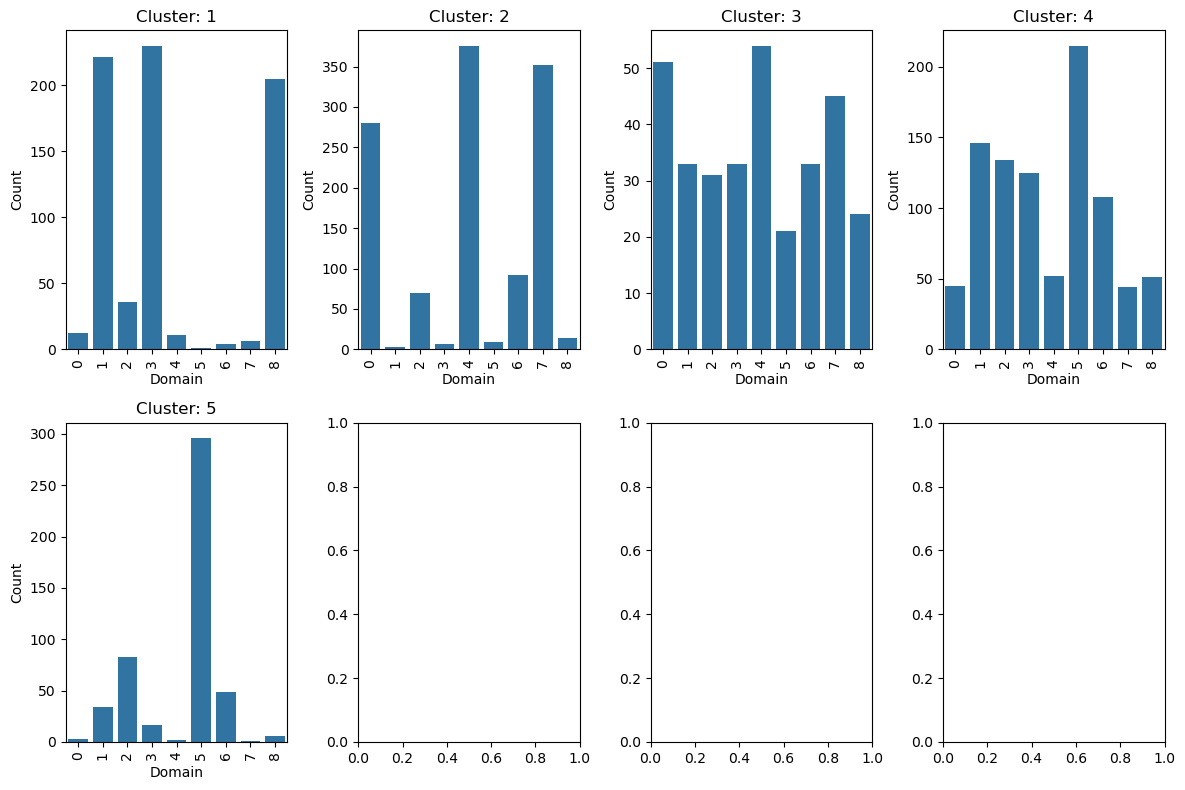

In [16]:
colors = ['#1f77b4', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94']
sns.set_palette(colors)

result = []
cluster = pd.DataFrame({'idx':idx, 'label':labels})
for i in np.unique(labels):
    data_new = cluster[cluster['label'] == i]
    idx_new = set(list(data_new['idx']))
    result_i = []
    for key in d.keys():
        idx_key = set(list(d[key]))
        result_i.append(len(idx_key.intersection(idx_new)))
    result.append(result_i)
result = pd.DataFrame(np.array(result).T)
result.index = d.keys()
#result.columns = ['1','2','3','4','5','6','7','8', '9']
result.columns = [str(i + 1) for i in range(result.shape[1])]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

for i, cluster in enumerate(result.columns):
    row, col = divmod(i, 4)
    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])
    axes[row, col].set_title(f'Cluster: {cluster}')
    axes[row, col].set_xticklabels(result.index, rotation=90)
    axes[row, col].set_xlabel('Domain')
    axes[row, col].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [17]:
from scipy.cluster.hierarchy import leaves_list

pdist_z = scale(pdist_)
pdist_z = (pdist_z + pdist_z.T) / 2
results_z = pd.DataFrame(pdist_z)

ii = leaves_list(Z)
results_z = results_z.iloc[ii, ii]

label_indexed = pd.DataFrame(results_z, index=range(len(labels)))

# 按照labels的顺序重新排列行
sorted_results_z = label_indexed.loc[np.argsort(labels), np.argsort(labels)]

In [18]:
name_map = {}
next_mod = 1
for i in sorted_results_z.index:
    mod = labels[i]
    if mod in name_map:
        continue
    if mod == -1:
        continue
    else:
        name_map[int(mod)] = "Module {}".format(next_mod)
        next_mod = next_mod + 1
name_map[-1] = "Module 0"

name_map_r = {v: k for k, v in name_map.items()}

In [19]:
colors = sns.color_palette("muted")
colormap = {i: colors[i % 10] if i != -1 else (1.0, 1.0, 1.0) for i in np.unique(labels)}
colormap_r = {v: k for k, v in colormap.items()}
row_colors1 = pd.Series(
    [colormap[i] for i in labels],
    index=range(10000),
)

row_colors = pd.DataFrame({"Module": row_colors1})
row_colors = row_colors.loc[sorted_results_z.index]

cmap = sns.diverging_palette(230, 20, sep=20, s=85, l=50, as_cmap=True)

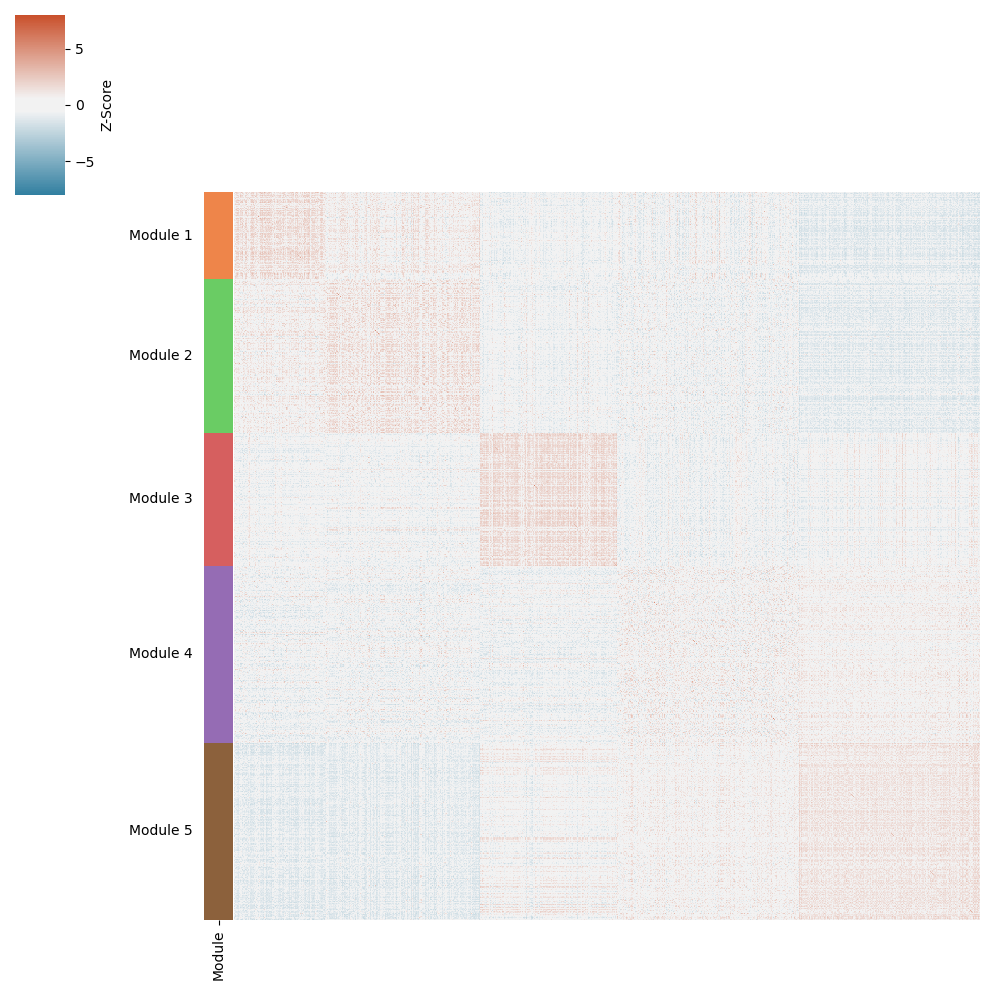

In [20]:
cm = sns.clustermap(
    sorted_results_z,
    row_cluster=False,
    col_cluster=False,
    vmin=-8,
    vmax=8,
    cmap=cmap,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    rasterized=True,
    cbar_kws=dict(
        label="Z-Score",
#         ticks=[-8, 0, 8],
    ),
)

fig = plt.gcf()
fig.patch.set_visible(False)
plt.sca(cm.ax_heatmap)
plt.ylabel("")
plt.xlabel("")

# Assuming row_colors is ordered, label the groups
plt.sca(cm.ax_row_colors)
for i in row_colors.Module.unique():
    if i == (1.0, 1.0, 1.0):
        continue
    mid = 0
    count = 0
    cl = colormap_r[i]
    for j, x in enumerate(row_colors.Module.values):
        if x == i:
            mid += j
            count += 1

    mid = mid/count

    plt.text(-.4, mid, name_map[cl],
             horizontalalignment='right',
             verticalalignment='center')

plt.show()

In [24]:
peak_modules = pd.Series(data=labels, index=atac.var_names[idx])  # or part of adata.var['module']

In [25]:
atac_10k = atac[:,idx].copy()

In [26]:
# x kb window
window = 50_000

# Prepare peak and gene DataFrames
peaks = atac_10k.var[['chrom', 'start', 'end']].copy()
peaks['peak_id'] = peaks.index
peaks['module'] = peak_modules.loc[peaks.index].values

genes = expr.var[['chrom', 'start', 'end']].copy()
genes['gene_id'] = genes.index

# Make sure coordinates are integers
peaks[['start', 'end']] = peaks[['start', 'end']].astype(int)
# Drop genes with missing coordinates
genes = genes.dropna(subset=['start', 'end'])

# Now safely cast to integers
genes[['start', 'end']] = genes[['start', 'end']].astype(int)
# Initialize output list
links = []

# Iterate chromosome by chromosome (faster, avoids cross-chromosome comparisons)
for chrom in peaks['chrom'].unique():
    peaks_chr = peaks[peaks['chrom'] == chrom]
    genes_chr = genes[genes['chrom'] == chrom]

    # For each peak, find genes within ±100 kb
    for i, peak in peaks_chr.iterrows():
        peak_center = (peak['start'] + peak['end']) // 2
        gene_subset = genes_chr[
            (genes_chr['start'] <= peak_center + window) &
            (genes_chr['end'] >= peak_center - window)
        ]
        for _, gene in gene_subset.iterrows():
            links.append({
                'peak_id': peak['peak_id'],
                'gene_id': gene['gene_id'],
                'module': peak['module'],
                'distance': min(abs(gene['start'] - peak_center), abs(gene['end'] - peak_center))
            })

# Convert to DataFrame
links_df = pd.DataFrame(links)


In [27]:
module_gene_map = links_df.groupby('module')['gene_id'].apply(set).to_dict()

In [28]:
def write_genes(m_g_map, r, num_clusters):
    
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_gene_lists", exist_ok=True)
    
    # Write each module's gene list to a separate .txt file
    for module, genes in m_g_map.items():
        filename = f"{r}_{num_clusters}_module_gene_lists/module_{module}_genes.txt"
        with open(filename, 'w') as f:
            for gene in sorted(genes):  # sorted for readability
                f.write(f"{gene}\n")
        print(f"✅ Saved: {filename} ({len(genes)} genes)")

In [29]:
def write_peak_modules(peak_df, r, num_clusters):
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_peak_beds", exist_ok=True)

    for module_id in range(1, num_clusters+1):
        module_peaks = peak_df[peak_df['module'] == module_id]
    
        bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
        bed_df['score'] = 0
        bed_df['strand'] = '.'
    
        bed_df.to_csv(
            f'{r}_{num_clusters}_module_peak_beds/peak_module_{module_id}.bed',
            sep='\t',
            header=False,
            index=False
        )
    
        print(f"Wrote peak_module_{module_id}.bed with {len(bed_df)} peaks")

In [48]:
write_peak_modules(peaks, r, 5)

Wrote peak_module_1.bed with 1193 peaks
Wrote peak_module_2.bed with 2113 peaks
Wrote peak_module_3.bed with 1829 peaks
Wrote peak_module_4.bed with 2439 peaks
Wrote peak_module_5.bed with 2426 peaks


In [49]:
write_genes(module_gene_map, r, 5)

✅ Saved: 0.5_5_module_gene_lists/module_1_genes.txt (1697 genes)
✅ Saved: 0.5_5_module_gene_lists/module_2_genes.txt (2744 genes)
✅ Saved: 0.5_5_module_gene_lists/module_3_genes.txt (2751 genes)
✅ Saved: 0.5_5_module_gene_lists/module_4_genes.txt (4245 genes)
✅ Saved: 0.5_5_module_gene_lists/module_5_genes.txt (4331 genes)


In [80]:
all_genes = expr.var_names  # or atac_all_peaks.var_names
'''
with open("enrichr_background_genes.txt", "w") as f:
    for gene in all_genes:
        f.write(f"{gene}\n")
'''

'\nwith open("enrichr_background_genes.txt", "w") as f:\n    for gene in all_genes:\n        f.write(f"{gene}\n")\n'

## Which celltypes are modules enriched in?

In [32]:
for module in sorted(peak_modules.unique()):
    peak_ids = peak_modules[peak_modules == module].index
    atac.obs[f'module_{module}_score'] = atac[:, peak_ids].X.mean(axis=1)


In [82]:
for module in sorted(peak_modules.unique()):
    print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))


subclass
L6 CT         0.948011
L6 IT         0.782107
L5 IT         0.724480
L5 ET         0.668037
L6 IT Car3    0.627509
Name: module_1_score, dtype: float32
subclass
L2/3 IT    0.807134
L4/5 IT    0.787741
L5 IT      0.719086
L6 IT      0.684560
L5 ET      0.625094
Name: module_2_score, dtype: float32
subclass
Endo       1.276115
PVM        0.905275
Peri       0.772614
L2/3 IT    0.714722
L4/5 IT    0.704109
Name: module_3_score, dtype: float32
subclass
Oligo    0.813420
Micro    0.790349
Astro    0.771293
VLMC     0.768384
OPC      0.722264
Name: module_4_score, dtype: float32
subclass
Oligo    1.163275
Astro    1.119958
Endo     1.081831
Peri     0.987141
OPC      0.981259
Name: module_5_score, dtype: float32


/tmp/ipykernel_2277943/998575007.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))
